1-5

Install / check version


In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

TensorFlow version: 2.19.0
Keras version: 3.13.2


Manual gradient in NumPy


In [3]:
import numpy as np

def f(x):
    return x ** 2

def gradient(x):
    return 2 * x

x = 5.0
learning_rate = 0.1

for _ in range(10):
    x -= learning_rate * gradient(x)

print("NumPy manual optimization result:")
print("x =", x, ", f(x) =", f(x))

NumPy manual optimization result:
x = 0.5368709120000001 , f(x) = 0.2882303761517119


Automatic gradient with TensorFlow / Keras backend


In [4]:
import tensorflow as tf

x = tf.Variable(5.0)

with tf.GradientTape() as tape:
    y = x ** 2

grad = tape.gradient(y, x)

print("Automatic gradient from TensorFlow:", grad.numpy())

Automatic gradient from TensorFlow: 10.0


Matrix multiplication speed test


In [5]:
import numpy as np
import tensorflow as tf
import time

size = (1000, 1000)
A = np.random.rand(*size)
B = np.random.rand(*size)

start = time.time()
C_numpy = np.dot(A, B)
print("NumPy Time:", time.time() - start)

A_tf = tf.constant(A)
B_tf = tf.constant(B)

start = time.time()
C_tf = tf.matmul(A_tf, B_tf)
print("TensorFlow Time:", time.time() - start)

NumPy Time: 0.04694509506225586
TensorFlow Time: 0.08015894889831543


Keras has built-in layers and activations


In [6]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation="sigmoid")
print(layer)

<Dense name=dense, built=False>


Dense layer example


In [7]:
from tensorflow.keras.layers import Dense

layer = Dense(
    units=64,
    activation="sigmoid",
    use_bias=True,
    kernel_initializer="glorot_uniform"
)

print(layer)

<Dense name=dense_1, built=False>


Load and preprocess MNIST

Training set: (60000, 28, 28, 1) (60000, 10)
Testing set: (10000, 28, 28, 1) (10000, 10)


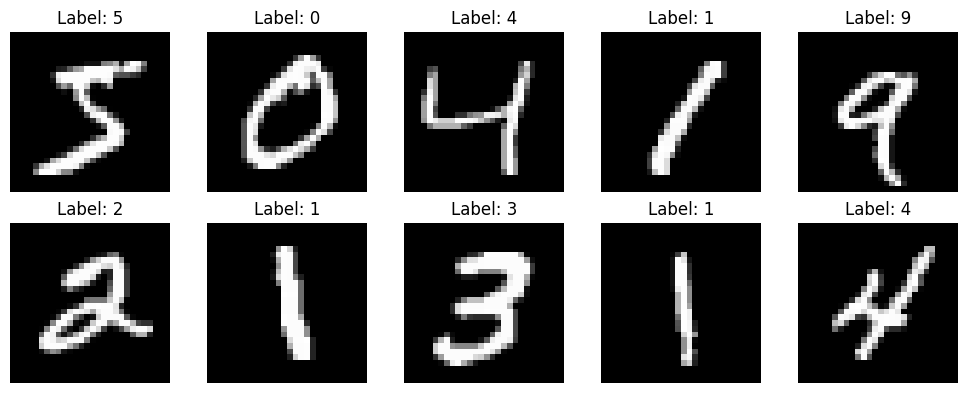

In [8]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# reshape for keras input
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# one-hot encode labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print("Training set:", x_train.shape, y_train.shape)
print("Testing set:", x_test.shape, y_test.shape)

# show some images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

Build Sequential model

In [10]:
from tensorflow import keras

num_classes = 10
input_shape = (28, 28, 1)

model = keras.Sequential([
    keras.layers.Input(shape=input_shape),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(num_classes, activation="softmax"),
])


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Functional API version


In [11]:
from tensorflow import keras

def build_functional_model():
    inputs = keras.Input(shape=(28, 28, 1))
    x = keras.layers.Flatten()(inputs)
    x = keras.layers.Dense(64, activation="sigmoid")(x)
    x = keras.layers.Dense(128, activation="sigmoid")(x)
    x = keras.layers.Dense(256, activation="sigmoid")(x)
    outputs = keras.layers.Dense(10, activation="softmax")(x)
    return keras.Model(inputs=inputs, outputs=outputs)

functional_model = build_functional_model()
functional_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Compile model

In [12]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


Train model

In [13]:
batch_size = 128
epochs = 20

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="mnist_best_model.keras",
        save_best_only=True,
        monitor="val_loss",
        mode="min"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )
]

history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6852 - loss: 1.0143 - val_accuracy: 0.8960 - val_loss: 0.3787
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9104 - loss: 0.3138 - val_accuracy: 0.9317 - val_loss: 0.2419
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9340 - loss: 0.2250 - val_accuracy: 0.9440 - val_loss: 0.1961
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9481 - loss: 0.1756 - val_accuracy: 0.9528 - val_loss: 0.1636
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9579 - loss: 0.1447 - val_accuracy: 0.9538 - val_loss: 0.1592
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9644 - loss: 0.1232 - val_accuracy: 0.9592 - val_loss: 0.1366
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9682 - loss: 0.1072 - val_accuracy: 0.9620 - val_loss: 0.1267
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9722 - loss: 0.0946 - val_accuracy: 0.

Visualize training progress

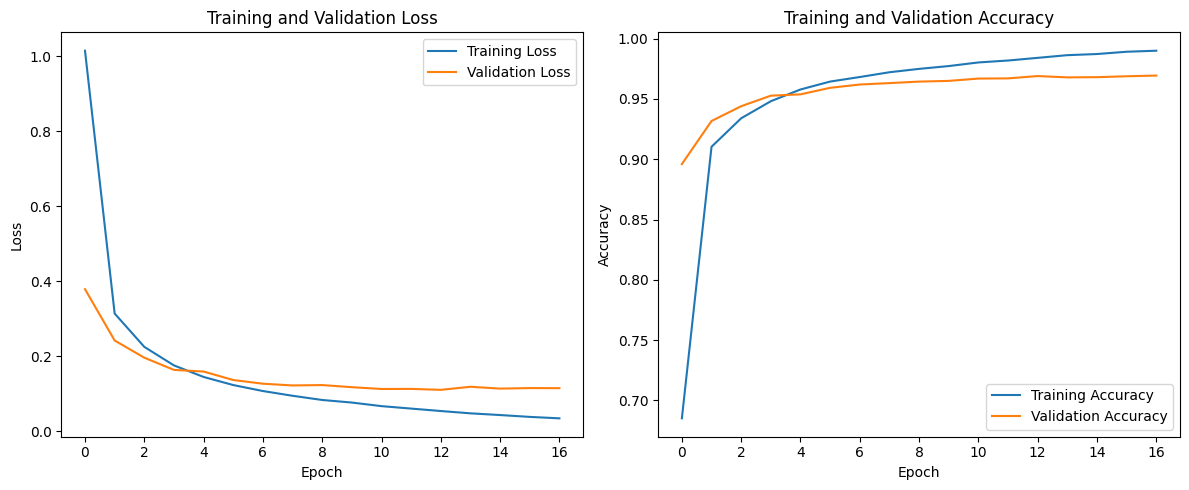

In [14]:
import matplotlib.pyplot as plt

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

Evaluate model

In [15]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.9691 - loss: 0.1066
Test Loss: 0.10655281692743301
Test Accuracy: 0.9690999984741211


Make predictions

In [16]:
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted label for first image:", predicted_labels[0])
print("True label for first image:", np.argmax(y_test[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted label for first image: 7
True label for first image: 7


Save and load model

In [17]:
model.save("mnist_fully_connected_model.h5")
print("Model saved.")

loaded_model = tf.keras.models.load_model("mnist_fully_connected_model.h5")
print("Model loaded.")

loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_acc)

Model saved.
Model loaded.
313/313 - 1s - 3ms/step - accuracy: 0.9691 - loss: 0.1066
Loaded Model Test Loss: 0.10655281692743301
Loaded Model Test Accuracy: 0.9690999984741211
